In [233]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.utils.class_weight import compute_class_weight
#ponderi de clasa pentru a compensa dezechilibrul

from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout

In [201]:
data = pd.read_csv('../data/Churn_Modelling.csv')

In [202]:
data.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [203]:
data.tail(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9990,9991,15798964,Nkemakonam,714,Germany,Male,33,3,35016.60,1,1,0,53667.08,0
9991,9992,15769959,Ajuluchukwu,597,France,Female,53,4,88381.21,1,1,0,69384.71,1
9992,9993,15657105,Chukwualuka,726,Spain,Male,36,2,0.00,1,1,0,195192.40,0
9993,9994,15569266,Rahman,644,France,Male,28,7,155060.41,1,1,0,29179.52,0
9994,9995,15719294,Wood,800,France,Female,29,2,0.00,2,0,0,167773.55,0
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [204]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [205]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [206]:
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [ ]:
data.shape#

(10000, 14)

In [208]:
data.dtypes

RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [209]:
data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [210]:
data.duplicated().sum()

np.int64(0)

In [211]:
data.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

<Axes: >

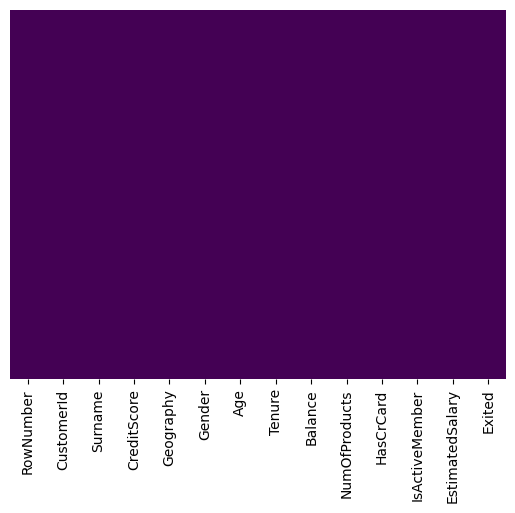

In [212]:
sns.heatmap(data.isnull(), yticklabels=False, cbar=False, cmap='viridis')

# Exploratory data analysis

In [213]:
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [214]:
categorical_cols = [
    'Geography', 'Gender'
]

le = LabelEncoder()

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [215]:
data.dtypes

CreditScore          int64
Geography            int64
Gender               int64
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [216]:
data.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
5,645,2,1,44,8,113755.78,2,1,0,149756.71,1
6,822,0,1,50,7,0.00,2,1,1,10062.80,0
7,376,1,0,29,4,115046.74,4,1,0,119346.88,1
8,501,0,1,44,4,142051.07,2,0,1,74940.50,0
9,684,0,1,27,2,134603.88,1,1,1,71725.73,0


# Training and testing data

In [217]:
X = data.drop("Exited", axis=1)
y = data["Exited"]

In [218]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [ ]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (7000, 10)
Test set size: (3000, 10)


In [220]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training and fitting the model

In [221]:
#creating the model
model = Sequential()

In [222]:
#input layer, 10 columns
model.add(Input(shape=(10,)))

In [223]:
#first hidden layer - 64 neurons, Relu activation function
model.add(Dense(64, activation='relu'))

#second hidden layer
model.add(Dense(32, activation='relu'))

In [ ]:
#output layer - 1 neuron with Sigmoid (return value between 0 and 1)
model.add(Dense(1, activation='sigmoid'))

In [225]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [226]:
#compiling the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [227]:
#training the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8077 - loss: 0.4585 - val_accuracy: 0.8213 - val_loss: 0.4104
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - accuracy: 0.8327 - loss: 0.4029 - val_accuracy: 0.8430 - val_loss: 0.3712
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - accuracy: 0.8490 - loss: 0.3736 - val_accuracy: 0.8543 - val_loss: 0.3492
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - accuracy: 0.8546 - loss: 0.3594 - val_accuracy: 0.8567 - val_loss: 0.3431
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - accuracy: 0.8549 - loss: 0.3528 - val_accuracy: 0.8537 - val_loss: 0.3430
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - accuracy: 0.8576 - loss: 0.3477 - val_accuracy: 0.8633 - val_loss: 0.3351
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - accuracy: 0.8576 - loss: 0.3444 - val_accuracy: 0.8570 - val_loss: 0.3436
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step - accuracy: 0.8559 - loss: 0.3416 - va

# Model Evaluation

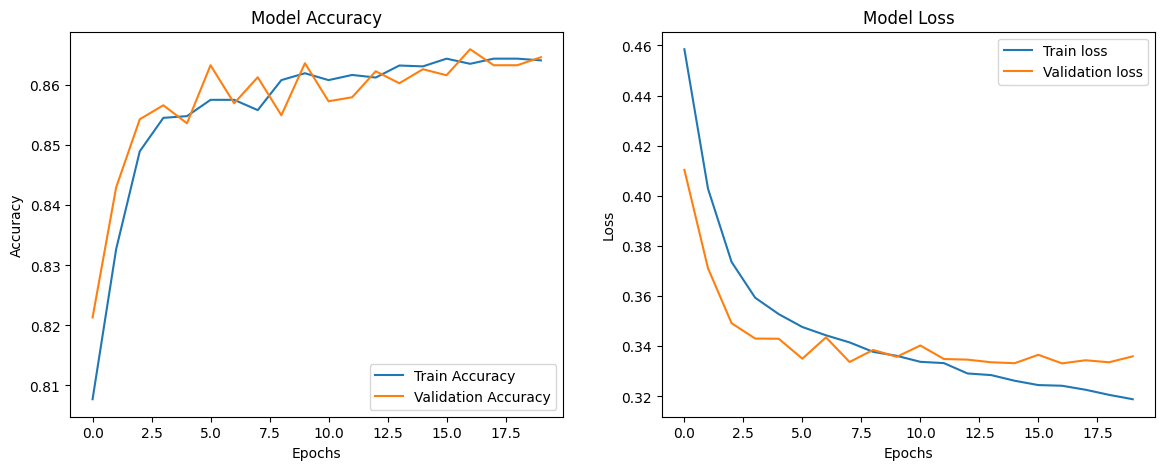

In [228]:
#Plotting accuracy and loss functions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Accuracy plot
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

#Loss plot
ax2.plot(history.history['loss'], label='Train loss')
ax2.plot(history.history['val_loss'], label='Validation loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

In [229]:
# results
y_pred = (model.predict(X_test)>0.5).astype(int)

print("Accuracy score:", accuracy_score(y_test, y_pred))

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification report:\n", classification_report(y_test, y_pred))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step
Accuracy score: 0.8646666666666667

Confusion matrix:
 [[2270  108]
 [ 298  324]]

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.92      2378
           1       0.75      0.52      0.61       622

    accuracy                           0.86      3000
   macro avg       0.82      0.74      0.77      3000
weighted avg       0.86      0.86      0.86      3000



It can be observed that according to the predictions, more employees tend to stay in the company than to leave: 2378 vs. 622. The data is imbalanced.

# ANN optimization (add class weights for imbalanced data)

In [230]:
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)

class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(0.6266786034019696), 1: np.float64(2.4734982332155475)}


In [231]:
# retrain model with weighted classes
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), class_weight=class_weights_dict)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step - accuracy: 0.7964 - loss: 0.4485 - val_accuracy: 0.8233 - val_loss: 0.3837
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - accuracy: 0.8021 - loss: 0.4373 - val_accuracy: 0.7740 - val_loss: 0.4761
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - accuracy: 0.8016 - loss: 0.4333 - val_accuracy: 0.8003 - val_loss: 0.4264
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - accuracy: 0.8056 - loss: 0.4302 - val_accuracy: 0.7940 - val_loss: 0.4312
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 701us/step - accuracy: 0.8060 - loss: 0.4272 - val_accuracy: 0.8140 - val_loss: 0.4126
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - accuracy: 0.8046 - loss: 0.4249 - val_accuracy: 0.7847 - val_loss: 0.4480
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - accuracy: 0.8053 - loss: 0.4238 - val_accuracy: 0.7983 - val_loss: 0.4274
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - accuracy: 0.8076 - loss: 0.4199 - 

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy Score:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step
Accuracy Score: 0.8043333333333333

Confusion Matrix:
 [[1960  418]
 [ 169  453]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.82      0.87      2378
           1       0.52      0.73      0.61       622

    accuracy                           0.80      3000
   macro avg       0.72      0.78      0.74      3000
weighted avg       0.84      0.80      0.82      3000



[[1960  418] - out of 2378 who stay: 1960 correct, 418 wrong
[ 169  453]] - out of 622 who leave: 453 correct, 169 wrong
The model detects 73% of clients who leave, much better
Overall accuracy 80%, solid
Class 1 (leaves) has recall 0.73 - out of 622 clients who leave, the model finds 453

In [234]:
# optimization methods
model = Sequential()

model.add(Input(shape=(10,)))

#first hidden layer
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

#second hidden layer
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

#third
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

#forth
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

In [235]:
#outplut layer
model.add(Dense(1, activation='sigmoid'))

In [236]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,001 (187.50 KB)

 Trainable params: 47,041 (183.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
#compile the model, declaration of the optimizer
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [239]:
#train the model
history_optimized = model.fit(X_train, y_train,
                                        epochs=20,
                                        batch_size=32,
                                        validation_data=(X_test, y_test),
                                        class_weight=class_weights_dict)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5953 - loss: 0.7131 - val_accuracy: 0.7493 - val_loss: 0.5428
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6686 - loss: 0.6112 - val_accuracy: 0.7613 - val_loss: 0.4869
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7121 - loss: 0.5643 - val_accuracy: 0.7737 - val_loss: 0.4686
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7204 - loss: 0.5543 - val_accuracy: 0.7767 - val_loss: 0.4660
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7246 - loss: 0.5361 - val_accuracy: 0.7643 - val_loss: 0.4772
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7371 - loss: 0.5270 - val_accuracy: 0.7830 - val_loss: 0.4657
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7483 - loss: 0.5175 - val_accuracy: 0.7920 - val_loss: 0.4541
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7396 - loss: 0.5205 - val_accuracy: 0.

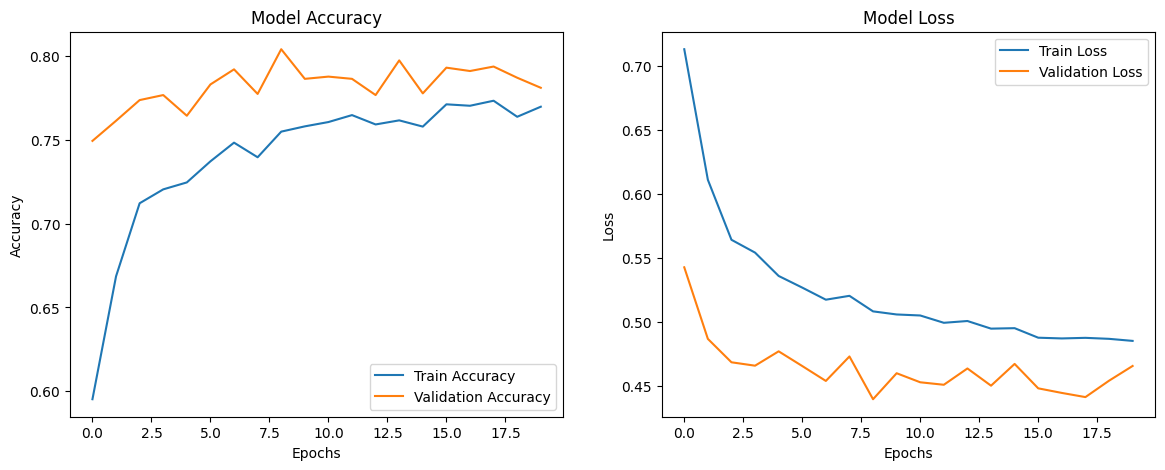

In [240]:
#plot accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_optimized.history['accuracy'], label='Train Accuracy')
ax1.plot(history_optimized.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history_optimized.history['loss'], label='Train Loss')
ax2.plot(history_optimized.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

In [ ]:
y_pred_opt = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy Score:", accuracy_score(y_test, y_pred_opt))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_opt))

print("\nClassification Report:\n", classification_report(y_test, y_pred_opt))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy Score: 0.781

Confusion Matrix:
 [[1860  518]
 [ 139  483]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.78      0.85      2378
           1       0.48      0.78      0.60       622

    accuracy                           0.78      3000
   macro avg       0.71      0.78      0.72      3000
weighted avg       0.84      0.78      0.80      3000



The optimized model made a trade-off, it misclassifies class 0 (stays) slightly more but detects class 1 (leaves) better, which is more valuable for the bank